# Types de rapports & de déposants au Sénat — d'où sort le « 42 % de PTR »

> **Jumeau Sénat** de `docs/ANALYSE_FILING_TYPES_HOUSE.md` (Chambre). Fenêtre **2014-2026**, tous déposants.

**La question.** La Chambre publie un index annuel qui déclare le *type* de chaque dépôt (une lettre
parmi douze) — on lit « P » pour les PTR, hors ligne. Le **Sénat n'a pas d'index public** : le portail
**eFD** (`efdsearch.senate.gov`) se **filtre** par type de rapport (*Report Type*) et par type de
déposant (*Filer Type*). Ce notebook ré-interroge le portail pour documenter, chiffre par chiffre, la
répartition affichée sur la **slide 1e** du deck (`SLIDES_DONNEES_S1S2_V2.tex`).

**Ce qu'on établit**
1. le **dénominateur** — 5 096 dépôts tous types — et la **preuve** que la fenêtre 2014-2026 est bien appliquée ;
2. la répartition **par *Report Type*** (les 5 types du formulaire ; somme = 100 %) ;
3. la répartition **par *Filer Type*** (Senator / Former Senator / Candidate) et le PTR de chacun ;
4. les **figures** de la slide 1e.

> ⚠️ Contrairement à la Chambre (index XML rejouable hors-ligne), ces chiffres viennent d'un **scrape
> du portail** : ré-exécuter ce notebook les rafraîchit (le portail peut évoluer de quelques unités).

In [1]:
%matplotlib inline
import time, json
from pathlib import Path
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams.update({"font.size": 12, "font.family": "DejaVu Sans"})

def _find_repo():
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / "common").is_dir() and (d / "data").is_dir():
            return d
    raise RuntimeError("module introuvable (attendu : dossier contenant common/ et data/)")

REPO     = _find_repo()
FIG_DIR  = REPO / "docs" / "slides";  FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = REPO / "data" / "senate";  DATA_DIR.mkdir(parents=True, exist_ok=True)

# charte du deck (mêmes hex que le préambule Beamer : selec = Sénat, socr = Sénat clair)
SELEC = "#8E44AD"; SOCR = "#CFAEDE"; GRAY = "#C8CCD0"; INK = "#2b2b2b"
def fr(n): return f"{int(n):,}".replace(",", " ")   # 2160 -> "2 160"

print("module :", REPO)

module : /Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees


## §1 · Accéder au portail — la barrière CSRF

Avant toute recherche, eFD impose d'**accepter un accord** (case obligatoire) et délivre un **jeton de
session (CSRF)**. On reproduit ici le geste du collecteur (`senate/census_probe.py`) : accepter l'accord,
puis interroger le point d'accès `/search/report/data/` qui renvoie un `recordsTotal`. Chaque mesure =
**une requête**, avec une pause polie ; lecture seule (on ne lit que des compteurs).

In [2]:
EFD        = "https://efdsearch.senate.gov"
EFD_HOME   = f"{EFD}/search/home/"
EFD_SEARCH = f"{EFD}/search/"
EFD_DATA   = f"{EFD}/search/report/data/"

S = requests.Session()
S.headers.update({"User-Agent": "congress-trading-research/1.0 (poli, sans evasion)",
                  "Accept-Language": "en-US,en;q=0.9"})

def accept_agreement():
    S.get(EFD_HOME, timeout=60)
    tok = S.cookies.get("csrftoken", "")
    S.post(EFD_HOME, data={"prohibition_agreement": "1", "csrfmiddlewaretoken": tok},
           headers={"Referer": EFD_HOME, "X-CSRFToken": tok}, timeout=60)
    return "csrftoken" in S.cookies

def efd_count(report_types="[]", filer_types="[]", start="01/01/2014", end="12/31/2026"):
    # recordsTotal d'une recherche eFD (une requête + pause polie)
    tok = S.cookies.get("csrftoken", "")
    h = {"Referer": EFD_SEARCH, "X-CSRFToken": tok, "X-Requested-With": "XMLHttpRequest"}
    p = {"draw": "1", "start": "0", "length": "1", "search[value]": "", "search[regex]": "false",
         "order[0][column]": "4", "order[0][dir]": "desc",
         "report_types": report_types, "filer_types": filer_types,
         "submitted_start_date": f"{start} 00:00:00", "submitted_end_date": f"{end} 23:59:59",
         "candidate_state": "", "senator_state": "", "office_id": "", "first_name": "", "last_name": ""}
    r = S.post(EFD_DATA, data=p, headers=h, timeout=60)
    r.raise_for_status()
    time.sleep(1.5)
    return int(r.json()["recordsTotal"])

assert accept_agreement(), "accord eFD refusé"
print("session eFD ouverte")

session eFD ouverte


## §2 · Le dénominateur, et la preuve que la fenêtre 2014-2026 est bien appliquée

`report_types=[]` + `filer_types=[]` = **tous** les dépôts. On mesure la fenêtre du projet (2014-2026)
et, en contrôle, la fenêtre *all-time* : si le filtre de date fonctionne, l'all-time doit être
**strictement supérieur** (il inclut le pré-2014). Sinon, on lirait le même nombre — signe que « 5 096 »
serait en réalité « tout ».

In [3]:
TOTAL   = efd_count("[]", "[]")                                          # 2014-2026
ALLTIME = efd_count("[]", "[]", start="01/01/2000", end="12/31/2030")    # contrôle
print(f"tous types, 2014-2026 : {TOTAL}")
print(f"tous types, all-time  : {ALLTIME}   -> exclut {ALLTIME - TOTAL} dépôts hors 2014-2026")
assert ALLTIME > TOTAL, "le filtre de date semble IGNORÉ (all-time == fenêtre) !"
print("OK : le filtre de date est appliqué, le 5 096 est bien borné à 2014-2026.")

tous types, 2014-2026 : 5096
tous types, all-time  : 6045   -> exclut 949 dépôts hors 2014-2026
OK : le filtre de date est appliqué, le 5 096 est bien borné à 2014-2026.


## §3 · Répartition par *Report Type*

Le formulaire eFD expose **cinq** *Report Types* : *Annual*, *Periodic Transactions*, *Due Date
Extension*, *Blind Trusts*, *Other Documents*. On interroge les quatre non nuls (le cinquième,
*Other Documents*, vaut 0 sur la période). Seul le code **11 = PTR** est attesté dans le repo
(`census_probe.py`) ; les autres sont identifiés par le portail (slug d'URL + libellé de cellule).

In [4]:
RT_CODES = [("Annual", 7), ("Periodic Transactions", 11),
            ("Due Date Extension", 10), ("Blind Trusts", 14)]
report_types = (pd.DataFrame([{"report_type": n, "code": c, "dépôts": efd_count(f"[{c}]", "[]")}
                              for n, c in RT_CODES])
                  .sort_values("dépôts", ascending=False).reset_index(drop=True))
report_types["part_%"] = (100 * report_types["dépôts"] / TOTAL).round(1)
print("shape:", report_types.shape)
display(report_types)

shape: (4, 4)


,report_type,code,dépôts,part_%
0,Annual,7,2165,42.5
1,Periodic Transactions,11,2160,42.4
2,Due Date Extension,10,753,14.8
3,Blind Trusts,14,18,0.4


### §3.1 · Contrôle — la partition est propre (aucun recoupement)

Les quatre types doivent **sommer exactement** au total (le solde = *Other Documents*, attendu 0).
C'est le point qui distingue une vraie partition d'une somme gonflée par des amendements comptés en
double.

In [5]:
somme = int(report_types["dépôts"].sum())
print(f"somme des Report Types = {somme}   |   total tous types = {TOTAL}   |   Other Documents = {TOTAL - somme}")
assert somme == TOTAL, "la partition par Report Type ne somme pas au total !"
PTR = int(report_types.loc[report_types.report_type == "Periodic Transactions", "dépôts"].iloc[0])
print(f"OK : partition propre. Part des PTR = {PTR} / {TOTAL} = {100*PTR/TOTAL:.1f} %.")

somme des Report Types = 5096   |   total tous types = 5096   |   Other Documents = 0
OK : partition propre. Part des PTR = 2160 / 5096 = 42.4 %.


## §4 · Répartition par *Filer Type* (+ le PTR de chaque déposant)

Le portail expose **trois** *Filer Types* : *Senator*, *Candidate*, *Former Senator*. Pour chacun, on
mesure ses dépôts (tous types) **et** ses PTR (`report_types=[11]`). C'est ce qui montre *qui* dépose —
et *qui* trade réellement.

In [6]:
FT_CODES = [("Senator", 1), ("Former Senator", 5), ("Candidate", 4)]
filer_types = pd.DataFrame([{"filer_type": n, "code": c,
                             "dépôts": efd_count("[]", f"[{c}]"),
                             "dont_PTR": efd_count("[11]", f"[{c}]")} for n, c in FT_CODES])
filer_types["part_%"]        = (100 * filer_types["dépôts"]   / TOTAL).round(1)
filer_types["part_du_PTR_%"] = (100 * filer_types["dont_PTR"] / PTR).round(1)
print("shape:", filer_types.shape)
display(filer_types)

shape: (3, 6)


,filer_type,code,dépôts,dont_PTR,part_%,part_du_PTR_%
0,Senator,1,3370,1479,66.1,68.5
1,Former Senator,5,1216,668,23.9,30.9
2,Candidate,4,510,13,10.0,0.6


### §4.1 · Contrôle — les déposants partitionnent le total et le PTR

In [7]:
assert int(filer_types["dépôts"].sum())   == TOTAL, "les déposants ne somment pas au total !"
assert int(filer_types["dont_PTR"].sum()) == PTR,   "les PTR par déposant ne somment pas au PTR total !"
cand = filer_types.set_index("filer_type")
print(f"OK. Lecture : les candidats ne tradent quasi pas ({int(cand.loc['Candidate','dont_PTR'])} PTR) ;")
print(f"les anciens sénateurs pèsent {cand.loc['Former Senator','part_du_PTR_%']:.0f} % des PTR "
      f"(mandat de 6 ans + obligation de déclarer après le départ).")

OK. Lecture : les candidats ne tradent quasi pas (13 PTR) ;
les anciens sénateurs pèsent 31 % des PTR (mandat de 6 ans + obligation de déclarer après le départ).


## §5 · Les deux figures de la slide 1e

Même facture que `fig_filingtypes.png` de la Chambre : barres horizontales, **une barre mise en avant**
(le PTR, en violet Sénat), le reste grisé, étiquettes de données. La figure est écrite dans
`docs/slides/fig_senat_types.png` et montée sur la slide 1e.

figure écrite : /Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/docs/slides/fig_senat_types.png


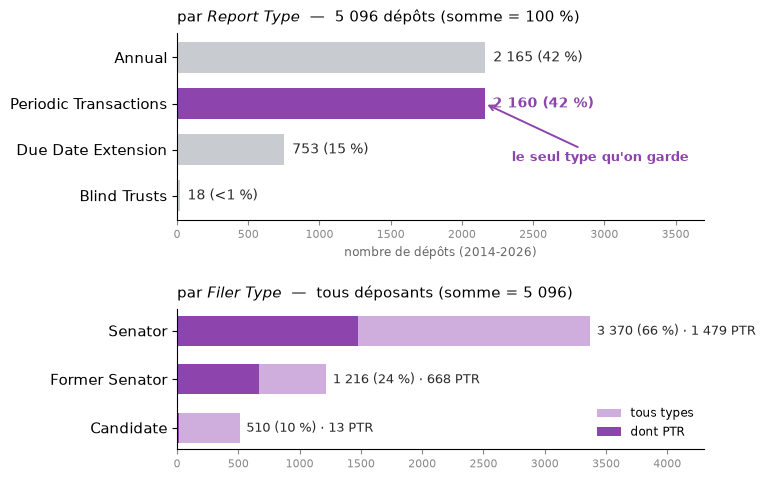

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.8, 5.4),
                               gridspec_kw={"height_ratios": [4, 3], "hspace": 0.55})

# --- panel 1 : Report Type (PTR en avant, le reste grisé) ---
d1 = report_types.iloc[::-1]                       # le plus grand en haut
cols = [SELEC if t == "Periodic Transactions" else GRAY for t in d1["report_type"]]
y = range(len(d1))
ax1.barh(y, d1["dépôts"], color=cols, height=0.68)
ax1.set_yticks(list(y)); ax1.set_yticklabels(d1["report_type"], fontsize=10.5)
for i, (t, v, p) in enumerate(zip(d1["report_type"], d1["dépôts"], d1["part_%"])):
    b = (t == "Periodic Transactions"); ptxt = "<1 %" if p < 1 else f"{p:.0f} %"
    ax1.text(v + 55, i, f"{fr(v)} ({ptxt})", va="center", fontsize=10,
             fontweight="bold" if b else "normal", color=SELEC if b else INK)
ptr_y = list(d1["report_type"]).index("Periodic Transactions")
ax1.annotate("le seul type qu'on garde", xy=(PTR, ptr_y), xytext=(2350, 0.75),
             fontsize=9.5, fontweight="bold", color=SELEC,
             arrowprops=dict(arrowstyle="->", color=SELEC, lw=1.4))
ax1.set_xlim(0, 3700)
ax1.set_title("par $\\it{Report\\ Type}$  —  5 096 dépôts (somme = 100 %)", fontsize=11, loc="left", pad=8)
ax1.set_xlabel("nombre de dépôts (2014-2026)", fontsize=8.5, color="#666")
ax1.spines[["top", "right"]].set_visible(False); ax1.tick_params(axis="x", labelsize=8, colors="#888")

# --- panel 2 : Filer Type (barre totale claire + PTR foncé en surimpression) ---
d2 = filer_types.iloc[::-1]
y2 = range(len(d2))
ax2.barh(y2, d2["dépôts"],   color=SOCR,  height=0.62, label="tous types")
ax2.barh(y2, d2["dont_PTR"], color=SELEC, height=0.62, label="dont PTR")
ax2.set_yticks(list(y2)); ax2.set_yticklabels(d2["filer_type"], fontsize=10.5)
for i, (t, p, pc) in enumerate(zip(d2["dépôts"], d2["dont_PTR"], d2["part_%"])):
    ax2.text(t + 55, i, f"{fr(t)} ({pc:.0f} %) · {fr(p)} PTR", va="center", fontsize=9.3, color=INK)
ax2.set_xlim(0, 4300)
ax2.set_title("par $\\it{Filer\\ Type}$  —  tous déposants (somme = 5 096)", fontsize=11, loc="left", pad=8)
ax2.spines[["top", "right"]].set_visible(False); ax2.tick_params(axis="x", labelsize=8, colors="#888")
ax2.legend(loc="lower right", fontsize=8.5, frameon=False)

fig.savefig(FIG_DIR / "fig_senat_types.png", dpi=150, bbox_inches="tight")
print("figure écrite :", FIG_DIR / "fig_senat_types.png")
plt.show()

## §6 · Persistance — on fige les deux répartitions

À côté du census PTR (`data/senate/_ptr_census_2014_2026.csv`), on écrit les deux tables pour qu'elles
soient rejouables et citables.

In [9]:
report_types.to_csv(DATA_DIR / "_report_types_2014_2026.csv", index=False)
filer_types.to_csv(DATA_DIR / "_filer_types_2014_2026.csv", index=False)
print("écrits :", DATA_DIR / "_report_types_2014_2026.csv")
print("        ", DATA_DIR / "_filer_types_2014_2026.csv")

écrits : /Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/senate/_report_types_2014_2026.csv
         /Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/senate/_filer_types_2014_2026.csv


## §7 · À périmètre égal avec la Chambre (apples-to-apples)

| | Chambre (index XML) | Sénat (portail eFD) |
|---|---|---|
| dénominateur | **35 315** dépôts tous types | **5 096** dépôts tous types |
| PTR | 8 252 | 2 160 |
| **part des PTR** | **23,4 %** | **42 %** |
| fenêtre | 2014-2026 | 2014-2026 |
| périmètre | tous types, tous déposants (candidats + anciens membres) | idem |

Les deux ratios sont « PTR ÷ tous les dépôts », **même fenêtre**, **même périmètre de déposants**.
Deux asymétries de **méthode** (pas de périmètre) : la répartition par déposant est **native** au Sénat
(*Filer Types*) mais seulement **dérivée** à la Chambre (aucun champ de statut) ; et « candidat » est un
type de **document** à la Chambre (type C) mais un type de **déposant** au Sénat. Détail :
`docs/ANALYSE_TYPES_RAPPORTS_SENAT.md`.